(06-36-inelastische-markten)=

# Demand systems en inelastische markten

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1986–2025: van Shleifers S&P 500-inclusies tot de *inelastic markets hypothesis* (de vraag naar aandelen reageert nauwelijks op de prijs) van
Gabaix en Koijen en het debat over passief beleggen.

**Wat we al weten.** Koersen bewegen meer dan dividendnieuws kan dragen
([](#03-15-shiller-excess-volatility)), en die beweging is statistisch dezelfde als
voorspelbaarheid van rendementen; of dat risico of vergissing is, konden prijzen alleen
niet beslissen ([](#05-33-fama-vs-shiller)). De vorige lecture liet machines honderden
voorspellers combineren zonder theorie ([](#06-35-machine-learning)), en in
[](#04-25-industrie) werd passief beleggen de grootste beleggersgroep op de beurs. Wat
ontbrak, was data over *wie* koopt en verkoopt, en een model waarin dat ertoe doet.

**Welke vraag staat open.** Hoeveel beweegt de prijs van de aandelenmarkt als er één
dollar extra in stroomt, en wat zegt het antwoord over wat de markt beweegt?
```

## Overzicht

In de standaardtheorie van deze reeks bepaalt de *stochastic discount factor* (SDF, de
random variabele waarmee payoffs worden verdisconteerd) de prijs, en doet de hoeveelheid die
iemand wil kopen er niet toe: wie zonder nieuws een miljard dollar in aandelen stopt, vindt
arbitrageurs die het verschil wegstrepen, want de vraagcurve voor aandelen is vlak. Deze lecture
gaat over het programma dat die aanname mat en verwierp. Koijen en Yogo
{cite}`KoijenYogo2019` schatten een vraagsysteem per institutionele belegger uit de
kwartaalposities die fondsbeheerders aan de SEC rapporteren. Gabaix en Koijen
{cite}`GabaixKoijen2021` tilden het naar de hele markt en concludeerden dat "investing \$1
in the stock market increases the market's aggregate value by about \$5". Santa-Clara vat
de draagwijdte samen: als dat klopt, is "a large share of the variation in prices that
Shiller called excess and Cochrane called discount rates" noch het een noch het ander,
"it is flows meeting inelastic supply" {cite}`SantaClara2026`.

Epistemisch is dit het eindpunt van motief 3: geen theorie die getoetst wordt, maar metingen
(elasticiteiten, de prijsimpact van *flows*, geldstromen van beleggers in of uit een markt,
en inclusie-effecten) die op een theorie wachten. Santa-Clara noemt de vraag wat de markt beweegt "the most important open question of the
current decade"; wat passief beleggen met prijzen doet, staat op dezelfde lijst van wat we niet
weten. De lecture geeft beide kanten: de inclusiestudies van Shleifer {cite}`Shleifer1986` tot Chang,
Hong en Liskovich {cite}`ChangHongLiskovich2015`, waarin vraagcurves voor aandelen dalen, en het
tegenargument van [](#02-06-efficiente-markten): een markt vol goed geïnformeerde handelaren.

We rekenen een markt met een passief fonds en een actieve belegger met de hand door,
bewijzen de multiplier $M = 1/\zeta$, laten zien waarom standaardmodellen een elasticiteit van
tientallen voorspellen, en behandelen het vraagsysteem van Koijen en Yogo en *granular instrumental variables*
(instrumenten uit de eigen schokken van grote beleggers). De simulaties tonen hoe inelastische
vraag *excess volatility* (koersen die meer bewegen dan fundamenteel nieuws rechtvaardigt) maakt,
en waarom een gewone regressie de elasticiteit niet meet. Op echte data regresseren we
kwartaalrendementen op de netto aandelenaankopen per sector uit de Financial Accounts van
de Federal Reserve, en meten we het inclusie-effect van veertien recente
S&P 500-toevoegingen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Op 16 november 2020 maakte S&P Dow Jones Indices bekend dat Tesla op 21 december in de
S&P 500 zou worden opgenomen. Er was geen nieuws over auto's, winst of rente, alleen een
zekerheid: elk indexfonds zou op die dag Tesla-aandelen moeten kopen, ongeacht de prijs. Is de
vraagcurve vlak, dan maakt dat niets uit. Daalt ze, dan moeten de indexfondsen de prijs
opdrijven tot iemand wil verkopen.

Andrei Shleifer bekeek die vraag in 1986: aandelen die sinds september 1976 in de index
kwamen, "have earned a significant positive abnormal return at the announcement of the
inclusion", en dat rendement hing samen met hoeveel indexfondsen moesten kopen
{cite}`Shleifer1986`. Een inclusie verandert niets aan de kasstromen; stijgt de prijs toch, dan
omdat er meer vraag is dan de markt zonder prijsverandering opvangt. Dat is de inhoud van
"demand curves slope down".

Voor één aandeel is dat te begrijpen: Tesla heeft geen perfect substituut, en "stocks without
close substitutes experience higher price jumps upon inclusion"
{cite}`WurglerZhuravskaya2002`. Voor de markt als geheel is er nog minder substituut. Wie
aandelen verkoopt aan iemand die geld in de markt stopt, moet zelf obligaties of kas gaan
houden. Het pensioenfonds met een mandaat van zestig procent aandelen doet dat niet, het
indexfonds evenmin. Als bijna iedereen aan zo'n mandaat vastzit, moet de prijs veel bewegen om
de weinige flexibele beleggers te overtuigen.

Gabaix en Koijen maken daar een getal van. Daalt de totale vraag naar aandelen met één
procent als de prijs vijf procent stijgt, dan is de *prijselasticiteit van de vraag* (de
procentuele daling in gevraagde hoeveelheid per procent prijsstijging) 0,2, en moet een
geldstroom van één procent van de marktwaarde de prijs vijf procent opdrijven. Eén dollar erin, vijf dollar marktwaarde erbij. Hun contrast met de theorie
is scherp: "most rational or behavioral models would predict a very small impact, about 100
times smaller, and a price elasticity about 100 times larger" {cite}`GabaixKoijen2021`.

Meten is lastig. Beleggers stoppen geld in aandelen als ze optimistisch zijn, en optimisme
beweegt ook prijzen: samenhang tussen instroom en rendement bewijst dus geen oorzaak. En elk
gekocht aandeel is door iemand verkocht. Wat een prijs beweegt, is niet dat er gekocht wordt,
maar dat de kopers minder gevoelig zijn voor de prijs dan de verkopers.

## Toy-voorbeeld: een passief fonds, een actieve belegger en één dollar

Er zijn $S = 100$ aandelen tegen een prijs $P_0 = 1$, dus een marktwaarde van 100. Twee
beleggers houden ze.

- **Het fonds** heeft een vermogen van 50 en een mandaat om een vaste fractie
  $\theta = 0{,}8$ in aandelen te houden: 40 aandelen en 10 aan obligaties.
- **De actieve belegger** houdt de andere 60 aandelen en heeft een vraagcurve
  $Q_A = a - b \log P$, met $a = 60$ en $b = 60\,\zeta_A$. Bij $P = 1$ wil hij 60 aandelen,
  en een prijsstijging van één procent verlaagt zijn vraag met $\zeta_A$ procent: $\zeta_A$
  is zijn prijselasticiteit.

**De elasticiteit van het fonds.** Stijgt de prijs met één procent, dan stijgen de
aandelen van het fonds naar 40,4 en het vermogen naar 50,4. Het mandaat eist
$0{,}8 \times 50{,}4 = 40{,}32$ in aandelen, dus het fonds verkoopt voor 0,08, oftewel
0,2% van zijn positie: elasticiteit $1 - \theta = 0{,}2$, want een prijsstijging neemt zijn
vermogen mee.

**De instroom.** Een spaarder stort 1 in het fonds. Bij ongewijzigde prijs wil het fonds
$0{,}8 \times 51 = 40{,}8$ in aandelen, dus 0,8 extra: de *geldstroom naar aandelen* is
$\theta \times 1 = 0{,}8$. Het aanbod is vast, dus de prijs stijgt tot beide samen weer 100
aandelen willen. Met $x$ de procentuele prijsstijging (in eerste orde) daalt de vraag van het
fonds met $0{,}2 \times 40\,x$ en die van de actieve belegger met $\zeta_A \times 60\,x$:

$$
0{,}8 = (0{,}2 \times 40 + \zeta_A \times 60)\, x .
$$

**Geval 1, $\zeta_A = 0{,}2$.** De haakjes zijn $8 + 12 = 20$, dus $x = 0{,}8/20 = 4\%$.
De marktwaarde stijgt met $\mathrm{d}P \cdot S = 0{,}04 \times 100 = 4$. Per dollar die naar
aandelen gaat, is dat $4/0{,}8 = 5$ dollar marktwaarde: de multiplier van Gabaix en Koijen.
De marktelasticiteit $(0{,}2 \times 40 + 0{,}2 \times 60)/100$ is $0{,}2$, en $5 = 1/0{,}2$.

**Geval 2, $\zeta_A = 5$.** De haakjes zijn $8 + 300 = 308$, dus
$x = 0{,}8/308 = 0{,}26\%$. De marktwaarde stijgt met 0,26 en de multiplier is
$0{,}26/0{,}8 = 0{,}32$. De marktelasticiteit is $3{,}08$, en $0{,}32 = 1/3{,}08$. Eén
elastische belegger met drie vijfde van de markt maakt de prijsimpact vijftien keer kleiner.

**Een verschuiving naar passief.** Blijf in geval 2, maar laat het fonds nu 70 aandelen
houden (vermogen 87,5) en de actieve belegger 30. De marktelasticiteit wordt
$(0{,}2 \times 70 + 5 \times 30)/100 = 1{,}64$, en dezelfde instroom geeft
$x = 0{,}8/164 = 0{,}49\%$, een multiplier van $0{,}61$: bijna twee keer zo veel als bij
40 aandelen. Niemand verandert van gedrag; het gewicht verschuift naar de belegger die nauwelijks op
prijzen reageert. In geval 1, waar beide even elastisch zijn, verandert de verschuiving
niets. Passief maakt de markt dus alleen inelastischer als de rest van de markt
elastischer was dan het mandaat.

In [2]:
def toy_market(zeta_active, equity_fund=40.0, equity_active=60.0, theta=0.8, inflow=1.0):
    """First-order price change in the two-investor toy market (shares = value at P0 = 1)."""
    market = equity_fund + equity_active
    zeta = ((1 - theta) * equity_fund + zeta_active * equity_active) / market
    x = theta * inflow / (zeta * market)
    return {"zeta markt": zeta, "prijsstijging (%)": 100 * x, "dP*S": x * market,
            "multiplier dP*S/(theta*instroom)": x * market / (theta * inflow)}


def toy_market_exact(zeta_active, equity_fund=40.0, equity_active=60.0, theta=0.8, inflow=1.0):
    """Exact clearing price: mandate fund Q = theta*W/P and active demand Q = a - b log P."""
    wealth = equity_fund / theta

    def excess_demand(log_p):
        price = np.exp(log_p)
        fund = theta * (wealth + inflow + equity_fund * (price - 1)) / price
        active = equity_active - zeta_active * equity_active * log_p
        return fund + active - (equity_fund + equity_active)

    return 100 * (np.exp(optimize.brentq(excess_demand, -0.5, 0.5)) - 1)


toy = pd.DataFrame({
    "zeta_A = 0.2": toy_market(0.2),
    "zeta_A = 5": toy_market(5.0),
    "zeta_A = 5, fonds 70": toy_market(5.0, equity_fund=70.0, equity_active=30.0),
}).T
toy["exact (%)"] = [toy_market_exact(0.2), toy_market_exact(5.0),
                    toy_market_exact(5.0, equity_fund=70.0, equity_active=30.0)]
hand = [4.0, 0.8 / 308 * 100, 0.8 / 164 * 100]
print("code == handberekening:", np.allclose(toy["prijsstijging (%)"], hand),
      "| multiplier = 1/zeta:", np.allclose(toy.iloc[:, 3], 1 / toy["zeta markt"]))
toy.round(4)

code == handberekening: True | multiplier = 1/zeta: True


,zeta markt,prijsstijging (%),dP*S,multiplier dP*S/(theta*instroom),exact (%)
zeta_A = 0.2,0.20,4.0000,4.0000,5.0000,3.9537
zeta_A = 5,3.08,0.2597,0.2597,0.3247,0.2594
"zeta_A = 5, fonds 70",1.64,0.4878,0.4878,0.6098,0.4867


De code geeft dezelfde getallen; de exacte marktclearing zonder eerste-ordebenadering (laatste
kolom) geeft 3,95% in plaats van 4% en 0,259% in plaats van 0,260%. 

## Theorie

### Opzet: mandaten, elasticiteiten en marktclearing

*Waarom zou dit waar zijn?* Bij een vast aanbod moet, als iemand meer wil houden, iemand
anders minder willen houden, en de prijs is het enige wat de rest daartoe beweegt. Hoe ver
de prijs moet gaan, hangt af van hoe gevoelig de rest voor de prijs is.

We volgen de eenvoudigste vorm van het model van {cite:t}`GabaixKoijen2021`, in eigen
notatie. Er zijn $N$ beleggers $i$ en één geaggregeerde aandelenmarkt met een vast aantal
aandelen $S$ tegen prijs $P_t$. Belegger $i$ vraagt $Q_{i}(P_t)$ aandelen en houdt bij de
uitgangsprijs aandelen ter waarde $E_i = P_t Q_i$, met marktaandeel $s_i = E_i / \sum_j E_j$.
Zijn *prijselasticiteit* is

```{math}
:label: eq-inelastische-markten-elasticiteit
\zeta_i = -\frac{\partial \log Q_i}{\partial \log P},
```

en de elasticiteit van de markt is het waardegewogen gemiddelde
$\zeta = \sum_i s_i \zeta_i$. Een geldstroom $\Delta F_i$ is de verandering in de
dollarvraag van belegger $i$ bij ongewijzigde prijs. In deze sectie zijn kleine letters
logaritmische veranderingen: $p = \Delta \log P$.

:::{prf:lemma} Een fonds met een vast mandaat
:label: thm-inelastische-markten-mandaat

Een fonds met vermogen $W = B + PQ$ (obligaties plus aandelen) dat een vaste fractie
$\theta \in (0, 1]$ in aandelen houdt, heeft prijselasticiteit $\zeta = 1 - \theta$. Een
instroom $\Delta F$ in het fonds verhoogt zijn vraag naar aandelen bij ongewijzigde prijs
met $\theta\,\Delta F$ dollar.
:::

:::{prf:proof}
Na een prijsverandering en een instroom, maar vóór het herbalanceren, is het vermogen
$W(P) = B_0 + \Delta F + Q_0 P$. Het mandaat eist $Q(P) = \theta W(P)/P$. Dan is
$\partial Q/\partial P = -\theta (B_0 + \Delta F)/P^2$, en in het uitgangspunt
($\Delta F = 0$, $P = P_0$, $B_0 = (1-\theta) W_0$, $P_0 Q_0 = \theta W_0$)

$$
\zeta = -\frac{P_0}{Q_0}\frac{\partial Q}{\partial P}
= \frac{\theta B_0}{P_0 Q_0} = \frac{\theta (1-\theta) W_0}{\theta W_0} = 1 - \theta .
$$

Verder is $\partial Q/\partial \Delta F = \theta / P_0$, dus $P_0\,\Delta Q = \theta\,\Delta F$.
$\square$
:::

Een puur aandelenindexfonds ($\theta = 1$) heeft elasticiteit nul, een 60/40-fonds 0,4.
Een fonds dat zijn aandelenfractie bijstuurt naar het verwachte rendement, krijgt er een
elastisch deel bij; Gabaix en Koijen laten zulke bijsturing toe en schatten de elasticiteit
van instellingen desondanks "around 0.2" {cite}`GabaixKoijen2021`.

:::{prf:proposition} De flow-multiplier
:label: thm-inelastische-markten-multiplier

Laat elke belegger in eerste orde vragen
$\Delta Q_i / Q_i = -\zeta_i\, p + \Delta F_i / E_i$, en laat het aanbod vast zijn,
$\sum_i \Delta Q_i = 0$. Dan is, met $\Delta F = \sum_i \Delta F_i$ en $E = \sum_i E_i$,

```{math}
:label: eq-inelastische-markten-multiplier
p = \frac{1}{\zeta}\,\frac{\Delta F}{E},
\qquad
M \equiv \frac{\Delta (P S)}{\Delta F} = \frac{1}{\zeta}.
```

Een geldstroom die tussen beleggers wordt herverdeeld ($\Delta F = 0$) beweegt de prijs niet,
hoe groot de afzonderlijke stromen ook zijn.
:::

:::{prf:proof}
Vermenigvuldig de vraag van belegger $i$ met $P_0 Q_i = E_i$ en tel op:
$P_0 \sum_i \Delta Q_i = -p \sum_i \zeta_i E_i + \sum_i \Delta F_i$. Marktclearing maakt de
linkerkant nul, dus $p \sum_i \zeta_i E_i = \Delta F$ en $p = \Delta F/(\zeta E)$ met
$\zeta = \sum_i s_i \zeta_i$. De marktwaarde verandert in eerste orde met
$\Delta(PS) = p\,E$, dus $\Delta(PS)/\Delta F = 1/\zeta$. $\square$
:::

Twee opmerkingen voor de replicatie. *Netto aankopen* tellen over alle beleggers per
definitie op tot de netto uitgifte, want elk gekocht aandeel is verkocht; wat de prijs
beweegt, is $\Delta F$, de verschuiving in vraag bij de oude prijs, en die is niet
waarneembaar. En [](#eq-inelastische-markten-multiplier) zegt niets over wie de marginale
belegger is: een paar zeer elastische hedgefondsen kunnen $\zeta$ groot maken, als ze groot
genoeg zijn.

### Waarom standaardmodellen een elasticiteit van tientallen geven

*Waarom zou dit waar zijn?* Stijgt de prijs van een claim op een uitbetaling over een jaar
zonder nieuws met één procent, dan daalt het verwachte rendement met ongeveer één
procentpunt. Voor een belegger die vijf procent premie verdient, is dat een vijfde van zijn
premie, en een mean-variance-belegger houdt een positie die evenredig is met de premie: hij wil
een vijfde minder houden.

:::{prf:proposition} Elasticiteit van een mean-variance-belegger
:label: thm-inelastische-markten-cara

Een belegger met CARA-nut en risicoaversie $\gamma$ kiest $Q$ aandelen met payoff
$x_{t+1} \sim N(\mu_x, \sigma_x^2)$ per aandeel, bij een bruto risicovrij rendement
$R^{f}$. Zijn vraag is $Q = (\mu_x - R^{f} P)/(\gamma \sigma_x^2)$, en zijn
prijselasticiteit is

```{math}
:label: eq-inelastische-markten-cara
\zeta = \frac{R^{f}}{\E[R_{t+1}] - R^{f}},
\qquad \E[R_{t+1}] = \mu_x / P .
```
:::

:::{prf:proof}
Het eindvermogen is $W_0 R^{f} + Q(x_{t+1} - R^{f} P)$, normaal verdeeld, dus de belegger
maximaliseert $Q(\mu_x - R^{f}P) - \tfrac{\gamma}{2}Q^2\sigma_x^2$, met oplossing
$Q = (\mu_x - R^{f} P)/(\gamma\sigma_x^2)$. Dan is
$-\partial \log Q/\partial \log P = R^{f} P/(\mu_x - R^{f} P)$; deel teller en noemer door $P$.
$\square$
:::

Met een premie van vijf procent per jaar en $R^{f} \approx 1$ is $\zeta \approx 20$, honderd
keer de 0,2 van Gabaix en Koijen. Dat getal hoort bij een prijsafwijking die binnen het jaar terugloopt; een
permanente afwijking verlaagt het jaarlijkse verwachte rendement maar met ongeveer het
dividendrendement maal de prijsstijging, en geeft een veel lagere elasticiteit.

Voor een individueel aandeel met een substituut op een restrisico $\sigma_\varepsilon$ na
speelt $\sigma_\varepsilon^2$ de rol van $\sigma_x^2$, en gaat de elasticiteit naar oneindig als
$\sigma_\varepsilon \to 0$. Omdat aandelen geen perfecte substituten hebben, blijft er risico
over, en daarmee een eindige elasticiteit {cite}`WurglerZhuravskaya2002`.

In de SDF-taal van [](#05-33-fama-vs-shiller) is de vraagcurve volledig vlak: de prijs is
$P_t = \E_t[m_{t+1} x_{t+1}]$, en bij een representatieve belegger hangt $m_{t+1}$ af van
consumptie, niet van wie welk aandeel houdt. Wie wil dat flows prijzen bewegen, moet zeggen dat
de SDF die de prijs zet van de posities van specifieke beleggers afhangt, of dat hun
verwachtingen $\tilde{\mathbb P}$ met hun flows meebewegen: de dichtheid $\xi$ uit
{prf:ref}`prop-fama-vs-shiller-equivalentie`, nu gemeten via posities in plaats van enquêtes.

### Het vraagsysteem van Koijen en Yogo

*Waarom zou dit waar zijn?* Kiest elke belegger zijn portefeuille op basis van kenmerken van
aandelen (grootte, boekwaarde, winstgevendheid, bèta) en een eigen, onwaargenomen smaak, dan
zijn zijn gewichten een functie van die kenmerken plus ruis, per belegger te schatten uit zijn
posities. De gevoeligheid voor de eigen marktwaarde van een aandeel is de helling van zijn
vraagcurve.

{cite:t}`KoijenYogo2019` gebruiken de kwartaalposities van "institutions that manage more
than \$100 million since 1980", die samen 68 procent van de Amerikaanse beurs beheren
(NBER-werkversie van juli 2019, p. 4). Belegger $i$ heeft vermogen $A_i$ en een
beleggingsuniversum van aandelen $n$. Het gewicht van aandeel $n$ ten opzichte van het
buitenactivum $0$ is

```{math}
:label: eq-inelastische-markten-ky
\frac{w_i(n)}{w_i(0)} = \exp\!\Big(\beta_{0,i}\, \mathrm{me}(n) + \sum_{k} \beta_{k,i}\, x_k(n) + \beta_{K,i}\Big)\, \varepsilon_i(n),
```

met $\mathrm{me}(n)$ de log-marktwaarde, $x_k(n)$ kenmerken en $\varepsilon_i(n) \ge 0$ de
*latent demand* (de smaak van de belegger die de kenmerken niet verklaren). Het is een
logit-achtige vorm: de gewichten zijn exponentieel in de kenmerken en tellen samen met het
buitenactivum op tot één. 

:::{prf:proposition} Elasticiteit in het logit-vraagsysteem
:label: thm-inelastische-markten-ky-elasticiteit

Houd het vermogen $A_i$ en de kenmerken $x_k(n)$ vast. Dan is de prijselasticiteit van
belegger $i$ voor aandeel $n$

```{math}
:label: eq-inelastische-markten-ky-elasticiteit
\zeta_i(n) = -\frac{\partial \log Q_i(n)}{\partial \log P(n)} = 1 - \beta_{0,i}\,\big(1 - w_i(n)\big).
```

De vraag daalt in de prijs zolang $\beta_{0,i} < 1/(1 - w_i(n))$, en is volledig inelastisch
als $\beta_{0,i} = 1$ en het gewicht klein is.
:::

:::{prf:proof}
Schrijf $\delta(n)$ voor de rechterkant van [](#eq-inelastische-markten-ky). Omdat de
gewichten inclusief het buitenactivum optellen tot één, is
$w_i(n) = \delta(n)/(1 + \sum_m \delta(m))$, en dus
$\partial \log w_i(n)/\partial \log \delta(n) = 1 - w_i(n)$. De log-marktwaarde is
$\mathrm{me}(n) = \log P(n) + \log S(n)$, zodat $\partial \log \delta(n)/\partial \log P(n) = \beta_{0,i}$.
Het aantal gevraagde aandelen is $Q_i(n) = A_i w_i(n)/P(n)$, dus
$\partial \log Q_i(n)/\partial \log P(n) = \beta_{0,i}(1 - w_i(n)) - 1$. $\square$
:::

Met $\beta_{0,i} = 1$ belegt iemand als een indexfonds (elasticiteit nul), met
$\beta_{0,i} = 0$ houdt hij een vast dollarbedrag (elasticiteit één). Een elasticiteit van twintig vraagt een sterk
negatieve $\beta_{0,i}$, en die vinden de schattingen niet. {cite:t}`KoijenRichmondYogo2024`
rapporteren met dit systeem: "The price elasticity of demand is low on average and varies
from zero to one across investors. Even hedge funds, which are the most elastic among
institutional investors, have a wealth-weighted price elasticity of demand around 0.5"
(NBER-werkversie van september 2023, p. 3–4). Het zijn bovendien elasticiteiten op
korte termijn: {cite:t}`VanDerBeck2026` schat uit transacties op verschillende horizonnen
dat "price impacts are three times larger at quarterly horizons than in the long-run
equilibrium". In {cite:t}`KoijenYogo2019` zelf vonden we geen enkel getal voor de gemiddelde elasticiteit,
wel de prijsimpact van een vraagschok van tien procent bij de gemiddelde beleggingsadviseur in
de minst liquide aandelen: "from 0.64 percent in 1980 to 0.22 percent in 2017" (p. 4).

**Het identificatieprobleem.** Latent demand is zelf een vraagschok, en een hogere vraag
drijft de prijs en dus $\mathrm{me}(n)$ op. Een gewone schatting van $\beta_{0,i}$ is daardoor
naar boven vertekend: de vraag lijkt inelastischer dan ze is, of zelfs stijgend, alsof
beleggers meer kopen van wat duur is. Koijen en Yogo instrumenteren met de *universa* van
andere beleggers: "An asset that is included in the investment universe of more investors,
especially if those investors are large, has a larger exogenous component of demand" (p. 4).
Het instrument is de marktwaarde die een aandeel zou hebben "if other investors were to hold an
equal-weighted portfolio within their investment universe" (p. 19), met als universum wat een
belegger nu houdt of in de voorgaande elf kwartalen hield. De uitsluitingsrestrictie is dat die
universa niet samenhangen met de latente vraag van belegger $i$.

In hun variantiedecompositie van de cross-sectie van rendementen "explain only 12 percent"
de drie effecten aan de aanbodkant, terwijl "changes in latent demand are the most important,
explaining 81 percent" (p. 5): de meeste koersbewegingen van individuele aandelen zijn
vraagverschuivingen die geen kenmerk uit de factor zoo van [](#06-34-factor-zoo) verklaart.

### Granular instrumental variables

*Waarom zou dit waar zijn?* Om een helling te meten is een vraagverschuiving nodig die niets
met de prijs te maken heeft, en voor de hele markt bestaat geen universum-instrument. Maar de
markt bestaat uit een paar zeer grote spelers. Verkoopt één groot pensioenfonds om eigen redenen
(een nieuw bestuur, een herzien mandaat), dan is dat een schok die niet uit het sentiment komt en
door zijn omvang toch de prijs beweegt. Het verschil tussen de groottegewogen en de gelijkgewogen
flow isoleert zulke schokken, omdat gemeenschappelijke schokken in beide gemiddelden gelijk zijn.

{cite:t}`GabaixKoijen2024` formaliseren dat als "size-weighted sums of idiosyncratic shocks".
Neem de eenvoudigste versie. Sector $i$ heeft marktaandeel $S_i$ ($\sum_i S_i = 1$) en een
flow in procenten van zijn positie

```{math}
:label: eq-inelastische-markten-giv-model
f_{i,t} = -\zeta\, p_t + \eta_t + u_{i,t},
```

met $\eta_t$ een gemeenschappelijke vraagschok (sentiment, macronieuws) en $u_{i,t}$
idiosyncratische schokken, onafhankelijk over $i$ en van $\eta_t$, met variantie
$\sigma_u^2$. Het aanbod is vast, dus $\sum_i S_i f_{i,t} = 0$. Schrijf
$f_{E,t} = \tfrac1N \sum_i f_{i,t}$, $u_{E,t}$ en $u_{S,t} = \sum_i S_i u_{i,t}$, en
$H = \sum_i S_i^2$ voor de Herfindahl-index.

:::{prf:proposition} GIV identificeert de elasticiteit, OLS niet
:label: thm-inelastische-markten-giv

Laat $z_t = \sum_i S_i f_{i,t} - f_{E,t}$. Dan geldt

1. $z_t = u_{S,t} - u_{E,t}$ en $p_t = (\eta_t + u_{S,t})/\zeta$;
2. $\Cov(z_t, \eta_t + u_{E,t}) = 0$ en $\Cov(z_t, p_t) = \sigma_u^2 (H - 1/N)/\zeta$;
3. de GIV-schatter $\zeta^{\mathrm{GIV}} = -\Cov(z_t, f_{E,t})/\Cov(z_t, p_t)$ is gelijk aan
   $\zeta$ zodra $H > 1/N$;
4. de OLS-schatter van $f_{E,t}$ op $p_t$ heeft kansgrens

```{math}
:label: eq-inelastische-markten-ols-bias
\plim \hat\zeta^{\mathrm{OLS}} = \zeta\left(1 - \frac{\sigma_\eta^2 + \sigma_u^2/N}{\sigma_\eta^2 + \sigma_u^2 H}\right).
```
:::

:::{prf:proof}
(1) Marktclearing geeft $0 = -\zeta p_t + \eta_t + u_{S,t}$. Het gelijkgewogen gemiddelde
van [](#eq-inelastische-markten-giv-model) is $f_{E,t} = -\zeta p_t + \eta_t + u_{E,t}$, dus
$z_t = 0 - f_{E,t} = u_{S,t} - u_{E,t}$, want $-\zeta p_t + \eta_t = -u_{S,t}$.
(2) Met onafhankelijke $u_{i,t}$ is $\Cov(u_S, u_E) = \sigma_u^2 \sum_i S_i/N = \sigma_u^2/N$ en
$\Var(u_E) = \sigma_u^2/N$, dus $\Cov(z, u_E) = 0$; $\eta$ is onafhankelijk van $z$. Verder is
$\Cov(z, p) = (\Var(u_S) - \Cov(u_E, u_S))/\zeta = \sigma_u^2(H - 1/N)/\zeta$.
(3) $\Cov(z, f_E) = -\zeta \Cov(z, p) + \Cov(z, \eta + u_E) = -\zeta\Cov(z,p)$.
(4) $\Var(p) = (\sigma_\eta^2 + \sigma_u^2 H)/\zeta^2$ en
$\Cov(p, \eta + u_E) = (\sigma_\eta^2 + \sigma_u^2/N)/\zeta$, dus
$-\Cov(p, f_E)/\Var(p) = \zeta - \Cov(p, \eta + u_E)/\Var(p)$. $\square$
:::

Deel 4 is het probleem van elke naïeve schatting: domineren gemeenschappelijke vraagschokken
($\sigma_\eta^2 \gg \sigma_u^2$), dan gaat de OLS-schatter naar nul, want sectoren kopen samen
wanneer de prijs stijgt, en de regressie ziet vraag die nauwelijks op de prijs reageert. Deel 3
laat zien waar GIV zijn kracht vandaan haalt: uit $H - 1/N$, de mate waarin de markt *granular*
is. Met gelijke sectoren is het instrument nul. Omdat sectoren in de praktijk verschillend op
gemeenschappelijke schokken laden, halen Gabaix en Koijen die ladingen eerst met
hoofdcomponenten uit de flows. Op de Flow of Funds, 1993Q1–2018Q4, rapporteren ze in tabel 2 een multiplier van 7,08
(standaardfout 1,86) met één en 5,28 (1,10) met twee hoofdcomponenten, en over hun specificaties
"multiplier estimates ranging from 3.5 to 8" (NBER w28967, p. 26–28).

### Wat het verandert: excess volatility, passief beleggen en inkoop van eigen aandelen

*Waarom zou dit waar zijn?* Als een procent flow vijf procent prijs is, hoeven flows niet
groot te zijn om de koers beweeglijk te maken. En zolang flows traag terugdraaien, draaien
ook de prijsafwijkingen traag terug: de prijs-dividend-ratio voorspelt dan rendementen,
zonder dat iemand een hogere premie eist.

**Excess volatility.** Schrijf de log-prijs als fundamentele waarde plus het effect van
opgebouwde vraagverschuivingen, $\log P_t = v_t + c_t/\zeta$, met $c_t$ de cumulatieve
netto flow in procenten van de marktwaarde. Is $c_t$ een stationair AR(1)-proces met
persistentie $\phi$ en onafhankelijk van $v_t$, dan is

```{math}
:label: eq-inelastische-markten-volatiliteit
\Var(r_{t+1}) = \Var(\Delta v_{t+1}) + \frac{\Var(\Delta c_{t+1})}{\zeta^2},
\qquad
\E_t[r_{t+1}] - \E_t[\Delta v_{t+1}] = -\frac{1-\phi}{\zeta}\, c_t .
```

De eerste term is wat Shiller rechtvaardigbaar noemde, de tweede zijn excess volatility
([](#03-15-shiller-excess-volatility)). Met dividenden evenredig aan de fundamentele waarde is
de log prijs-dividend-ratio $c_t/\zeta$ plus een constante, en voorspelt ze rendementen met
helling $-(1-\phi)$: Cochrane's voorspelbaarheid, en dezelfde observationele gelijkwaardigheid
als in [](#05-33-fama-vs-shiller). Wie alleen prijzen en dividenden ziet, noemt dit een
tijdvariërende discontovoet.

**Passief beleggen.** Met een aandeel $s_P$ van indexfondsen met elasticiteit nul en een
actieve rest met elasticiteit $\zeta_A$ is $\zeta = (1 - s_P)\zeta_A$. Een verschuiving naar passief
verlaagt de marktelasticiteit mechanisch, zoals in het toy-voorbeeld. Maar actieve beleggers
kunnen agressiever gaan handelen; {cite:t}`HaddadHuebnerLoualiche2025` schatten dat die strategische
reactie "only counteracts two-thirds of the impact of the initial change in behavior", en
concluderen dat "the rise in passive investing over the last 20 years has made the demand for
individual stocks 11 percent more inelastic". {cite:t}`KoijenRichmondYogo2024` rekenen uit dat de daling van het geaggregeerde actieve
aandeel "from 38.9% in 2007.Q4 to 32.8% in 2016.Q4" een herwaardering van aandelen gaf die
"is quite large at 14%" (p. 5). Voor ETF's vonden
{cite:t}`BenDavidFranzoniMoussawi2018` dat "stocks with higher ETF ownership display
significantly higher volatility", met een risicopremie "of up to 56 basis points monthly".

**Inkoop van eigen aandelen.** Een onderneming die voor $\Delta F$ eigen aandelen inkoopt,
werkt in [](#eq-inelastische-markten-multiplier) als een instroom van $\Delta F$, zolang de
verkopers de opbrengst niet herbeleggen: de prijs per aandeel stijgt met $\Delta F/(\zeta E)$
en de marktwaarde verandert met ongeveer $(1/\zeta - 1)\Delta F$. Bij oneindige elasticiteit
is dat $-\Delta F$, de uitbetaling, zoals bij Miller en Modigliani
{cite}`MillerModigliani1961`; bij $\zeta = 0{,}2$ is het $+4\Delta F$. Een
financieringsbeslissing die er in de standaardtheorie niet toe doet, wordt zo een
koersbeweger.

**De tegenhanger.** Het klassieke antwoord staat in [](#02-06-efficiente-markten) en bij
{cite:t}`GrossmanStiglitz1980`: als flows prijzen van hun fundamentele waarde wegduwen, loont
het om geïnformeerd tegen die flows in te handelen, en die handelaren maken de vraag elastisch.
Een elasticiteit van 0,2 vraagt dus een verklaring waarom zo weinig kapitaal die rol speelt: de
limits of arbitrage van [](#04-23-behavioral), de kapitaalrestricties van
[](#05-32-intermediaries), of mandaten die ook professionals binden. De elasticiteit is geen
natuurconstante maar een evenwichtsuitkomst.

## Simulatie: flows, volatiliteit en het meten van een elasticiteit

### (a) Een economie waarin flows prijzen maken

We simuleren [](#eq-inelastische-markten-volatiliteit) op kwartaalbasis, honderd jaar lang,
in 2000 steekproeven per elasticiteit. De fundamentele waarde groeit met 1,5% per kwartaal
en een volatiliteit van 3,5%. De cumulatieve vraagverschuiving $c_t$ krijgt elk kwartaal
twee soorten schokken, elk met een standaarddeviatie van 0,8% van de marktwaarde:
willekeurige geldstromen van spaarders, en sentimentgedreven herallocaties waarbij
fondsen hun aandelenfractie bijstellen. Beide dooven uit met $\phi = 0{,}95$ per kwartaal,
een halfwaardetijd van ruim drie jaar. De flows zijn onafhankelijk van de fundamentele waarde. Een naïeve onderzoeker
regresseert rendementen op fundamenteel nieuws, vergelijkt beide volatiliteiten, en toetst of
de prijs-dividend-ratio rendementen voorspelt.

In [3]:
SD_V, MU_V, SD_FLOW, SD_SENTIMENT, PHI_FLOW = 0.035, 0.015, 0.008, 0.008, 0.95
ZETAS = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 20.0]


def simulate_flow_economy(n, T, zeta):
    """Quarterly log returns r = dv + dc / zeta with AR(1) cumulative flows c (fractions of market value).

    Returns returns (n, T), fundamental news dv (n, T) and the log price-dividend ratio minus its
    constant, c / zeta, observed at the start of each quarter (n, T).
    """
    dv = rng.normal(MU_V, SD_V, (n, T))
    shocks = rng.normal(0.0, SD_FLOW, (n, T)) + rng.normal(0.0, SD_SENTIMENT, (n, T))
    c = np.empty((n, T + 1))
    c[:, 0] = rng.normal(0.0, np.hypot(SD_FLOW, SD_SENTIMENT) / np.sqrt(1 - PHI_FLOW**2), n)
    for t in range(T):
        c[:, t + 1] = PHI_FLOW * c[:, t] + shocks[:, t]
    return dv + np.diff(c, axis=1) / zeta, dv, c[:, :-1] / zeta


def naive_researcher(r, dv, pd_ratio):
    """Row-wise statistics: annualised volatility, sigma(r)/sigma(dv), R2 of r on dv, PD slope and t-value."""
    rd, dvd = r - r.mean(1, keepdims=True), dv - dv.mean(1, keepdims=True)
    x = pd_ratio - pd_ratio.mean(1, keepdims=True)
    slope = (x * rd).sum(1) / (x**2).sum(1)
    resid = rd - slope[:, None] * x
    t_value = slope / np.sqrt((resid**2).sum(1) / (r.shape[1] - 2) / (x**2).sum(1))
    return {"vol": 2 * r.std(1), "ratio": r.std(1) / dv.std(1),
            "r2": (rd * dvd).sum(1) ** 2 / ((rd**2).sum(1) * (dvd**2).sum(1)),
            "slope": slope, "t": t_value}


var_dc = 2 * (SD_FLOW**2 + SD_SENTIMENT**2) / (1 + PHI_FLOW)
flow_sim = {zeta: naive_researcher(*simulate_flow_economy(2000, 400, zeta)) for zeta in ZETAS}
pd.DataFrame({
    zeta: {"vol. theorie (%/jr)": 200 * np.sqrt(SD_V**2 + var_dc / zeta**2),
           "vol. mediaan (%/jr)": 100 * np.median(s["vol"]),
           "vol. 5e-95e pct": f"{100 * np.percentile(s['vol'], 5):.1f}-{100 * np.percentile(s['vol'], 95):.1f}",
           "sigma(r)/sigma(dv)": np.median(s["ratio"]), "R2 op nieuws": np.median(s["r2"]),
           "PD-helling (mediaan)": np.median(s["slope"]), "P(t < -2)": np.mean(s["t"] < -2)}
    for zeta, s in flow_sim.items()
}).T.rename_axis("zeta").round(3)

,vol. theorie (%/jr),vol. mediaan (%/jr),vol. 5e-95e pct,sigma(r)/sigma(dv),R2 op nieuws,PD-helling (mediaan),P(t < -2)
zeta,,,,,,,
0.1,23.960973,23.954731,22.5-25.4,3.423333,0.08495,-0.057695,0.989
0.2,13.426915,13.403138,12.7-14.2,1.921416,0.272877,-0.058863,0.926
0.5,8.366907,8.358774,7.9-8.8,1.196822,0.700809,-0.057251,0.4405
1.0,7.365547,7.348016,6.9-7.8,1.052229,0.902906,-0.057666,0.1805
2.0,7.093153,7.091508,6.7-7.5,1.013183,0.973993,-0.062334,0.0775
5.0,7.014988,7.001848,6.6-7.4,1.002172,0.995721,-0.06625,0.0415
20.0,7.000938,6.981065,6.6-7.4,1.000116,0.999733,-0.036355,0.0215


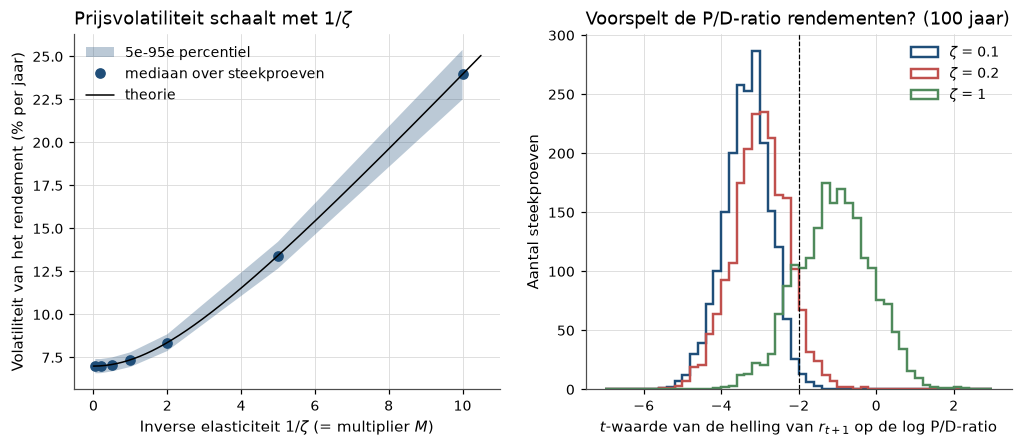

In [4]:
inverse = 1 / np.array(ZETAS)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
vol = np.array([np.percentile(flow_sim[z]["vol"], [5, 50, 95]) for z in ZETAS])
grid_inv = np.linspace(0, 10.5, 200)
axes[0].fill_between(inverse, 100 * vol[:, 0], 100 * vol[:, 2], alpha=0.3, label="5e-95e percentiel")
axes[0].plot(inverse, 100 * vol[:, 1], "o", color=hap.plotting.COLORS[0], label="mediaan over steekproeven")
axes[0].plot(grid_inv, 200 * np.sqrt(SD_V**2 + var_dc * grid_inv**2), color="black", lw=1,
             label="theorie")
axes[0].set_title("Prijsvolatiliteit schaalt met $1/\\zeta$")
axes[0].set_xlabel("Inverse elasticiteit $1/\\zeta$ (= multiplier $M$)")
axes[0].set_ylabel("Volatiliteit van het rendement (% per jaar)")
axes[0].legend()
for i, z in enumerate([0.1, 0.2, 1.0]):
    axes[1].hist(flow_sim[z]["t"], bins=np.linspace(-7, 3, 51), histtype="step", lw=1.6,
                 color=hap.plotting.COLORS[i], label=f"$\\zeta$ = {z:g}")
axes[1].axvline(-2, color="black", lw=0.8, ls="--")
axes[1].set_title("Voorspelt de P/D-ratio rendementen? (100 jaar)")
axes[1].set_xlabel("$t$-waarde van de helling van $r_{t+1}$ op de log P/D-ratio")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend()
plt.show()

:::{figure} #cel-inelastische-markten-flowsim
:label: fig-inelastische-markten-flowsim
:width: 100%

Links: dezelfde flows geven bij een elasticiteit van 2 of meer een volatiliteit die niet
van de fundamentele 7% per jaar te onderscheiden is, en bij $\zeta = 0{,}1$ ruim 24%. De
band over 2000 steekproeven is smal: een tweede moment is goed meetbaar. Rechts: de P/D-ratio voorspelt overal met dezelfde ware helling, maar alleen bij een lage
elasticiteit is dat in honderd jaar zichtbaar.
:::

De tabel en [](#fig-inelastische-markten-flowsim) maken drie punten. Ten eerste schaalt de
volatiliteit precies zoals [](#eq-inelastische-markten-volatiliteit) zegt: van 7,0% per
jaar bij $\zeta = 5$ naar 13,4% bij $\zeta = 0{,}2$ en 24,0% bij $\zeta = 0{,}1$, met
geldstromen van nog geen 1,2% van de marktwaarde per kwartaal. Ten tweede vindt de
naïeve onderzoeker bij $\zeta = 0{,}2$ een rendement dat 1,9 keer zo beweeglijk is als het
fundamentele nieuws, dat maar 27% van de rendementsvariantie verklaart, en een
prijs-dividend-ratio die in 93% van de steekproeven significant rendementen voorspelt.
Shillers excess volatility en Cochrane's voorspelbaarheid tegelijk, zonder dat iemand zijn
discontovoet verandert of zich over dividenden vergist. Ten
derde is de ware voorspellende helling overal $-(1-\phi) = -0{,}05$ per kwartaal (mediane
schatting door kleine-steekproefbias rond $-0{,}06$), maar bij $\zeta = 1$ ziet 18% van de
steekproeven haar en bij $\zeta = 20$ nog 2%: het 2%-motief, want de voorspelbaarheid is er
altijd, maar pas meetbaar als flows een groot deel van de variantie dragen.

Maar de volatiliteit identificeert $\Var(\Delta c)/\zeta^2$, niet $\zeta$: twee keer zo grote
flows en elasticiteit geven dezelfde koersen. Wie $\zeta$ wil kennen, moet flows apart meten, het
probleem van (b).

### (b) De elasticiteit schatten: OLS tegen GIV

Nu de meting. We simuleren [](#eq-inelastische-markten-giv-model) met een ware elasticiteit
$\zeta = 0{,}2$, dus een ware multiplier van 5. Gemeenschappelijke vraagschokken en
idiosyncratische schokken hebben elk een standaarddeviatie van 1% per kwartaal, en de
sectoren hebben groottes volgens een Zipf-verdeling ($S_i \propto 1/i$) of, ter
vergelijking, bijna gelijke groottes ($S_i \propto i^{-0{,}1}$). We variëren het
aantal kwartalen $T$ (104 is de steekproef van Gabaix en Koijen, 1993–2018) en het aantal
sectoren $N$, en schatten telkens de elasticiteit met OLS en met GIV.

In [5]:
def simulate_giv(n_sim, T, N, zeta=0.2, sd_common=0.01, sd_idio=0.01, zipf=1.0):
    """OLS and GIV estimates of the elasticity in the granular flow model, one per simulated sample."""
    sizes = np.arange(1, N + 1, dtype=float) ** -zipf
    sizes /= sizes.sum()
    common = rng.normal(0.0, sd_common, (n_sim, T, 1))
    idio = rng.normal(0.0, sd_idio, (n_sim, T, N))
    price = (common[..., 0] + idio @ sizes) / zeta
    flows = -zeta * price[..., None] + common + idio
    flow_eq = flows.mean(axis=2)
    giv = flows @ sizes - flow_eq
    dm = lambda a: a - a.mean(axis=1, keepdims=True)     # noqa: E731 - demean over time
    ols = -(dm(price) * dm(flow_eq)).sum(1) / (dm(price) ** 2).sum(1)
    iv = -(dm(giv) * dm(flow_eq)).sum(1) / (dm(giv) * dm(price)).sum(1)
    return ols, iv, (sizes**2).sum()


giv_rows, giv_draws = {}, {}
for T in (40, 104, 400):
    for N in (5, 20):
        for zipf in (1.0, 0.1):
            ols, iv, herfindahl = simulate_giv(4000, T, N, zipf=zipf)
            giv_draws[(T, N, zipf)] = (ols, iv)
            bias = 0.2 * (1 - (0.01**2 + 0.01**2 / N) / (0.01**2 + 0.01**2 * herfindahl))
            giv_rows[(T, N, "Zipf" if zipf == 1.0 else "bijna gelijk")] = {
                "H - 1/N": herfindahl - 1 / N, "OLS mediaan": np.median(ols), "OLS plim (formule)": bias,
                "GIV mediaan": np.median(iv),
                "GIV 5e-95e pct": f"{np.percentile(iv, 5):.2f} tot {np.percentile(iv, 95):.2f}",
                "P(3 < M < 8)": np.mean((iv > 1 / 8) & (iv < 1 / 3))}
pd.DataFrame(giv_rows).T.rename_axis(["T", "N", "groottes"]).round(3)

H - 1/N OLS mediaan OLS plim (formule) GIV mediaan  \
T   N  groottes                                                            
40  5  Zipf          0.080729    0.012688           0.012607    0.187373   
       bijna gelijk  0.000668    0.000114           0.000111    0.016249   
    20 Zipf          0.073316    0.013101           0.013053    0.181913   
       bijna gelijk  0.000343    0.000082           0.000065    0.012653   
104 5  Zipf          0.080729    0.012708           0.012607    0.198896   
       bijna gelijk  0.000668    0.000121           0.000111    0.032079   
    20 Zipf          0.073316    0.012997           0.013053    0.201399   
       bijna gelijk  0.000343    0.000063           0.000065    0.022509   
400 5  Zipf          0.080729    0.012582           0.012607    0.199515   
       bijna gelijk  0.000668    0.000107           0.000111    0.068732   
    20 Zipf          0.073316    0.012976           0.013053    0.200392   
       bijna gelijk  0.000343    0.000071           0.000065    0.052164   

                     GIV 5e-95e pct P(3 < M < 8)  
T   N  groottes                                   
40  5  Zipf           0.07 tot 0.96      0.57225  
       bijna gelijk  -0.21 tot 0.21      0.05325  
    20 Zipf          -0.36 tot 1.01      0.56675  
       bijna gelijk  -0.18 tot 0.17        0.037  
104 5  Zipf           0.12 tot 0.52       0.7975  
       bijna gelijk  -0.31 tot 0.39       0.1005  
    20 Zipf           0.12 tot 0.51        0.801  
       bijna gelijk  -0.30 tot 0.34       0.0735  
400 5  Zipf           0.15 tot 0.29      0.97975  
       bijna gelijk  -0.65 tot 0.71       0.1895  
    20 Zipf           0.15 tot 0.29       0.9795  
       bijna gelijk  -0.52 tot 0.60      0.14125

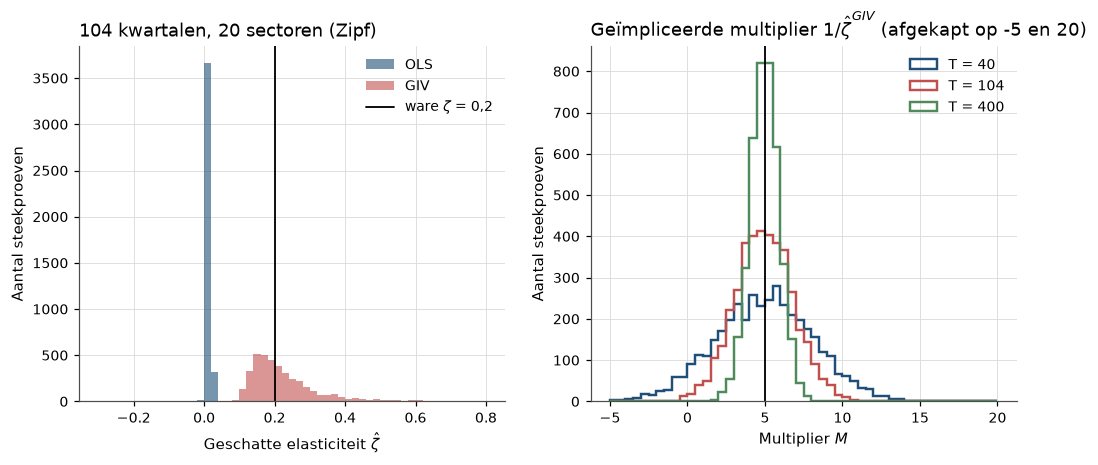

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
bins = np.linspace(-0.3, 0.8, 56)
ols_104, iv_104 = giv_draws[(104, 20, 1.0)]
axes[0].hist(ols_104, bins=bins, alpha=0.6, label="OLS")
axes[0].hist(iv_104, bins=bins, alpha=0.6, label="GIV")
axes[0].axvline(0.2, color="black", lw=1.2, label="ware $\\zeta$ = 0,2")
axes[0].set_title("104 kwartalen, 20 sectoren (Zipf)")
axes[0].set_xlabel("Geschatte elasticiteit $\\hat\\zeta$")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
for i, T in enumerate((40, 104, 400)):
    implied = 1 / giv_draws[(T, 20, 1.0)][1]
    axes[1].hist(np.clip(implied, -5, 20), bins=np.linspace(-5, 20, 51), histtype="step", lw=1.6,
                 color=hap.plotting.COLORS[i], label=f"T = {T}")
axes[1].axvline(5, color="black", lw=1.2)
axes[1].set_title("Geïmpliceerde multiplier $1/\\hat\\zeta^{GIV}$ (afgekapt op -5 en 20)")
axes[1].set_xlabel("Multiplier $M$")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend()
plt.show()

:::{figure} #cel-inelastische-markten-giv
:label: fig-inelastische-markten-giv
:width: 100%

Links: over 4000 steekproeven van 104 kwartalen ligt de OLS-schatter vlak bij nul, ver van
de ware elasticiteit, terwijl GIV rond 0,2 ligt. Rechts: de multiplier die bij de
GIV-schatting hoort, is scheef verdeeld. Met 40 kwartalen is hij vaak negatief of enorm;
met 400 kwartalen ligt hij bijna altijd tussen 3 en 8.
:::

Drie resultaten. De OLS-schatter heeft een mediaan van 0,013 bij elke $T$ en $N$, precies
de kansgrens uit [](#eq-inelastische-markten-ols-bias): een geïmpliceerde multiplier van
bijna 80. Meer data helpt niet: het is een bias, geen ruis. De GIV-schatter heeft met Zipf-groottes een mediaan van 0,20 zodra
$T \ge 104$. Het aantal sectoren doet er nauwelijks toe, omdat $H - 1/N$ bij 5 en bij 20
sectoren ongeveer even groot is. Met bijna gelijke sectoren is het instrument zwak: de mediaan
zakt naar 0,01–0,07, in de richting van OLS, en de multiplier valt in hooguit een op de vijf
steekproeven tussen 3 en 8. Zonder grote spelers is er geen identificatie.

En het 2%-motief: met 104 kwartalen, de steekproef van Gabaix en Koijen, ligt het
90%-interval van $\hat\zeta^{\mathrm{GIV}}$ tussen 0,12 en 0,51, een multiplier tussen ongeveer 2
en 8: dezelfde bandbreedte als de "3.5 to 8" die zij over hun specificaties rapporteren. De "\$5"
is het midden van een interval dat een kwart eeuw kwartaaldata niet smaller maakt; pas met 400
kwartalen krimpt het tot 0,15–0,29.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** (1) Xavier Gabaix en Ralph Koijen, *In Search of the Origins of Financial
Fluctuations: The Inelastic Markets Hypothesis*, NBER Working Paper 28967, 2021
{cite}`GabaixKoijen2021`. (2) Andrei Shleifer, *Do Demand Curves for Stocks Slope Down?*,
Journal of Finance 1986 {cite}`Shleifer1986`; Antti Petajisto, *The Index Premium and Its
Hidden Cost for Index Funds*, Journal of Empirical Finance 2011 {cite}`Petajisto2011`;
Robin Greenwood en Marco Sammon, *The Disappearing Index Effect*, Journal of Finance 2025
{cite}`GreenwoodSammon2025`. (3) Investment Company Institute, *Fact Book* 2020
{cite}`ICI2020`, zoals in [](#04-25-industrie).

**Wat.** (1) De multiplier van de geaggregeerde markt: GIV-schattingen van 7,08
(standaardfout 1,86) en 5,28 (1,10) in tabel 2 (Flow of Funds, 1993Q1–2018Q4), afgerond tot
"about \$5". (2) Het inclusie-effect en zijn verdwijning: volgens Petajisto (sectie 2) vond
Shleifer "an addition premium of 3% for the 1976–1983 period"; Petajisto's tabel 1 geeft
+8,8% voor S&P 500-toevoegingen van aankondiging tot opname over 1990–2005; volgens
Greenwood en Sammon is het effect gedaald "from an average of 7.4% in the 1990s to less than
1% over the past decade". (3) Het aandeel van indexfondsen in de Amerikaanse beurswaarde: 6%
in 2009 en 15% in 2019 (ICI 2020, figuur 2.9).

**Data hier.** (1) De Financial Accounts of the United States (Z.1) van de Federal Reserve,
via FRED met `hap.data.fred(...)`: netto aankopen van aandelen (transacties,
*seasonally adjusted annual rate*, in miljoenen dollars) door huishoudens (`HNOCESQ027S`),
beleggingsfondsen (`BOGZ1FA653064100Q`), ETF's (`BOGZ1FA563064100Q`), pensioenfondsen
(`BOGZ1FA593064105Q`), verzekeraars (`BOGZ1FA523064105Q`) en het buitenland
(`ROWCEAQ027S`), de netto uitgifte door niet-financiële ondernemingen (`NCBCEBQ027S`), de
netto aankopen door alle sectoren samen (`BOGZ1FA893064105Q`) en de marktwaarde van alle
aandelen (`BOGZ1LM893064105Q`); het kwartaalrendement van de markt uit
`hap.data.market_monthly()`; 1952Q1–2026Q2. (2) Dagkoersen van de 50 aandelen uit
[](#02-07-event-studies) via `hap.data.yahoo(...)` en het dagelijkse marktrendement via
`hap.data.market_daily()`. Veertien van die aandelen werden tussen 2012 en 2024 aan de
S&P 500 toegevoegd; de aankondigings- en opnamedata komen uit de persberichten van S&P Dow
Jones Indices. (3) `hap.data.market_daily()` voor de gerealiseerde volatiliteit.

**Verschil met het origineel.** (1) Gabaix en Koijen gebruiken de vintage van juni 2019, meer
sectoren, flows naar aandelen én obligaties, en GIV met hoofdcomponenten; wij doen
gelijktijdige OLS-regressies op de huidige Z.1-cijfers. In de Financial Accounts zijn
huishoudens grotendeels de restpost, zodat hun flows de meetfouten van alle andere sectoren
erven. OLS meet geen causaal effect, want flows reageren binnen het kwartaal zelf op
rendementen. (2) Greenwood en Sammon gebruiken alle toevoegingen van 1980–2020; wij hebben
veertien toevoegingen uit een steekproef van grote, succesvolle aandelen (survivorship),
marktgecorrigeerde rendementen, en geen tijdstip van de aankondiging: we nemen aan dat die
na sluiting kwam. (3) Het aandeel passief is een geciteerd getal en geen reeks.

**Verwachte afwijking.** (1) Een positieve gelijktijdige helling van het kwartaalrendement op
de netto aankopen door beleggingsfondsen en ETF's (in procenten van de marktwaarde), met een
orde van grootte die niet eenduidig als causale multiplier te lezen is. Een multiplier van
ongeveer 5 die als replicatie van Gabaix en Koijen kan gelden, verwachten we zonder hun data
en GIV niet. Een negatief teken wijst op een fout in de datering. (2) Een positief gemiddeld
aankondigingsrendement; zonder Tesla een gemiddeld rendement van aankondiging tot opname dat
binnen twee standaardfouten van nul ligt en in grootte dichter bij de "less than 1%" van
Greenwood en Sammon dan bij de 8,8% van Petajisto. (3) Geen trend in de marktvolatiliteit
die met het aandeel passief samenvalt: tien jaar volatiliteit wordt door crises
gedomineerd.
```

### (1) Netto aankopen en rendementen in de Financial Accounts

In [7]:
FOF_SERIES = {
    "huishoudens": "HNOCESQ027S",
    "beleggingsfondsen": "BOGZ1FA653064100Q",
    "ETF's": "BOGZ1FA563064100Q",
    "pensioenfondsen": "BOGZ1FA593064105Q",
    "verzekeraars": "BOGZ1FA523064105Q",
    "buitenland": "ROWCEAQ027S",
    "uitgifte niet-fin. bedrijven": "NCBCEBQ027S",
    "alle sectoren": "BOGZ1FA893064105Q",
}
raw_flows = pd.concat({name: hap_data.fred(sid)[sid] for name, sid in FOF_SERIES.items()}, axis=1, sort=True)
market_value = hap_data.fred("BOGZ1LM893064105Q")["BOGZ1LM893064105Q"]
raw_flows.index = raw_flows.index + pd.offsets.QuarterEnd(0)          # FRED stamps the quarter start
market_value.index = market_value.index + pd.offsets.QuarterEnd(0)

# annual rate / 4 = flow in the quarter, as a fraction of the market value at the start of the quarter
flows = raw_flows.div(4 * market_value.shift(1), axis=0)
flows["fondsen"] = flows["beleggingsfondsen"] + flows["ETF's"]

monthly_market = hap_data.market_monthly()["Mkt"]
quarterly_return = ((1 + monthly_market).resample("QE").prod() - 1).where(
    monthly_market.resample("QE").count() == 3).rename("rendement")
panel = pd.concat([quarterly_return, flows], axis=1, sort=True).loc["1952-03-31":"2026-06-30"]
panel = panel.dropna(subset=["rendement", "fondsen"])

first_etf_quarter = panel.index[panel["ETF's"].ne(0).argmax()]
print(f"{panel.index[0]:%Y-%m} t/m {panel.index[-1]:%Y-%m}: {len(panel)} kwartalen; "
      f"eerste kwartaal met ETF-aankopen: {first_etf_quarter:%Y-%m}")
(100 * panel.drop(columns="rendement").describe().loc[["mean", "std", "min", "max"]]).T.round(3)

1952-03 t/m 2026-06: 298 kwartalen; eerste kwartaal met ETF-aankopen: 1993-03


,mean,std,min,max
huishoudens,-0.263,0.501,-1.946,1.428
beleggingsfondsen,0.071,0.192,-0.529,0.766
ETF's,0.045,0.080,-0.110,0.395
pensioenfondsen,0.119,0.299,-1.301,1.559
verzekeraars,0.029,0.059,-0.257,0.258
buitenland,0.049,0.134,-0.585,0.532
uitgifte niet-fin. bedrijven,-0.111,0.348,-1.636,0.538
alle sectoren,0.074,0.374,-1.687,1.027
fondsen,0.116,0.183,-0.382,0.767


In [8]:
def flow_regression(frame, regressor, lags=4):
    """Contemporaneous regression of the quarterly market return on one flow series (Newey-West)."""
    fit = hap.newey_west(frame["rendement"], frame[[regressor]], lags=lags)
    used = frame[["rendement", regressor]].dropna()
    return {"helling": fit.params[regressor], "t (NW)": fit.tvalues[regressor], "R2": fit.rsquared,
            "sd flow (% MV)": 100 * used[regressor].std(), "kwartalen": int(fit.nobs),
            "vanaf": f"{used.index[0]:%Y}"}


regressors = ["fondsen", "beleggingsfondsen", "ETF's", "pensioenfondsen", "verzekeraars", "buitenland",
              "huishoudens", "uitgifte niet-fin. bedrijven", "alle sectoren"]
flow_table = pd.DataFrame({x: flow_regression(panel, x) for x in regressors}).T
flow_table.loc["fondsen, 1993-2018"] = flow_regression(panel.loc["1993":"2018"], "fondsen")
flow_table.loc["ETF's, 2000-2026"] = flow_regression(panel.loc["2000":], "ETF's")
flow_table.infer_objects().round(3)

,helling,t (NW),R2,sd flow (% MV),kwartalen,vanaf
fondsen,7.345,2.836,0.026,0.183,298,1952
beleggingsfondsen,5.928,2.210,0.019,0.192,298,1952
ETF's,4.035,0.737,0.002,0.080,298,1952
pensioenfondsen,-2.689,-1.183,0.009,0.299,298,1952
verzekeraars,-8.284,-0.954,0.003,0.059,298,1952
buitenland,5.380,1.134,0.008,0.134,298,1952
huishoudens,2.009,1.412,0.015,0.501,298,1952
uitgifte niet-fin. bedrijven,1.444,0.943,0.004,0.348,298,1952
alle sectoren,1.268,0.959,0.003,0.374,298,1952
"fondsen, 1993-2018",16.392,3.585,0.156,0.195,104,1993


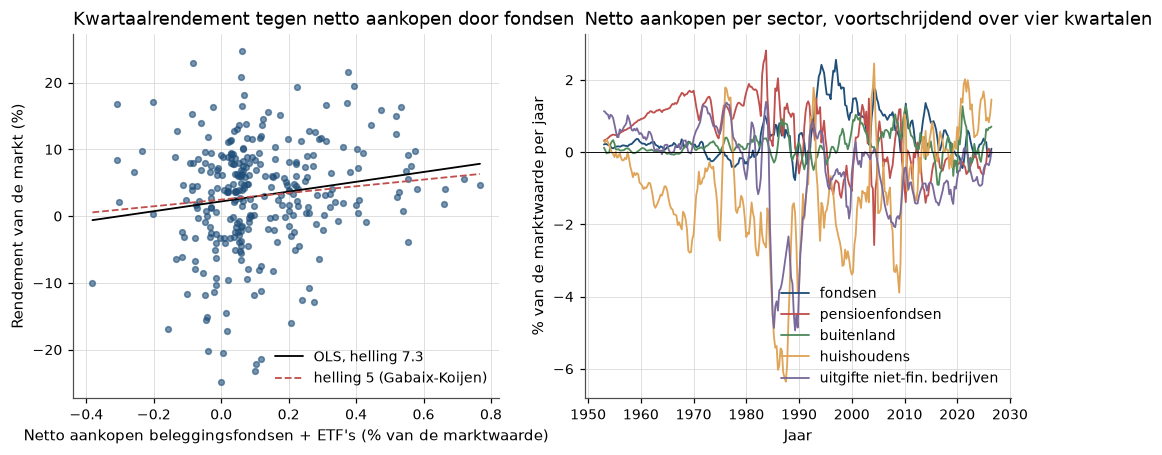

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
ok = panel[["fondsen", "rendement"]].dropna()
axes[0].scatter(100 * ok["fondsen"], 100 * ok["rendement"], s=14, alpha=0.6)
slope, intercept = np.polyfit(ok["fondsen"], ok["rendement"], 1)
grid_f = np.linspace(ok["fondsen"].min(), ok["fondsen"].max(), 50)
axes[0].plot(100 * grid_f, 100 * (intercept + slope * grid_f), color="black", lw=1.2,
             label=f"OLS, helling {slope:.1f}")
axes[0].plot(100 * grid_f, 100 * (ok["rendement"].mean() + 5 * (grid_f - ok["fondsen"].mean())),
             color=hap.plotting.COLORS[1], ls="--", lw=1.2, label="helling 5 (Gabaix-Koijen)")
axes[0].set_title("Kwartaalrendement tegen netto aankopen door fondsen")
axes[0].set_xlabel("Netto aankopen beleggingsfondsen + ETF's (% van de marktwaarde)")
axes[0].set_ylabel("Rendement van de markt (%)")
axes[0].legend()
for i, name in enumerate(["fondsen", "pensioenfondsen", "buitenland", "huishoudens", "uitgifte niet-fin. bedrijven"]):
    axes[1].plot(panel.index, 100 * panel[name].rolling(4).sum(), color=hap.plotting.COLORS[i], lw=1.2, label=name)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_title("Netto aankopen per sector, voortschrijdend over vier kwartalen")
axes[1].set_xlabel("Jaar")
axes[1].set_ylabel("% van de marktwaarde per jaar")
axes[1].legend()
plt.show()

De helling van het kwartaalrendement op de netto aankopen door fondsen is 7,3 ($t = 2{,}8$),
en over 1993–2018 16,4 ($t = 3{,}6$): positief, zoals verwacht, en van de orde van de multiplier
van Gabaix en Koijen. Maar de $R^2$ is 3%, pensioenfondsen en verzekeraars hebben een negatieve
helling (ze herbalanceren tegen de markt in), en de netto aankopen van alle sectoren samen, de
totale netto uitgifte, verklaren niets ($t = 1{,}0$). Een OLS-helling van 7 is geen multiplier
van 7: fondsflows reageren ook op het rendement zelf ([](#ex-inelastische-markten-3)).

### (2) Veertien S&P 500-toevoegingen

Eerst de gepubliceerde getallen. {cite:t}`HarrisGurel1986` vonden dat "immediately after an
addition is announced, prices increase by more than 3 percent", en dat die stijging "is nearly
fully reversed after 2 weeks"; Shleifer vond een rendement dat "does not disappear for at least
ten days after the inclusion". De tabel zet latere gemiddelden op een rij: geciteerde getallen met verschillende vensters,
geen eigen berekening.

In [10]:
published_index_effect = pd.DataFrame(
    [["Shleifer (1986), volgens Petajisto (2011)", "1976-1983", "S&P 500", "aankondiging", 3.0],
     ["Petajisto (2011), tabel 1", "1990-2000", "S&P 500", "aankondiging tot opname", 10.3],
     ["Petajisto (2011), tabel 1", "2001-2005", "S&P 500", "aankondiging tot opname", 4.6],
     ["Greenwood-Sammon (werkversie 2022)", "1980-1989", "S&P 500", "dag voor aankondiging tot dag na opname", 3.42],
     ["Greenwood-Sammon (werkversie 2022)", "1990-1999", "S&P 500", "dag voor aankondiging tot dag na opname", 7.6],
     ["Greenwood-Sammon (werkversie 2022)", "2000-2009", "S&P 500", "dag voor aankondiging tot dag na opname", 5.21],
     ["Greenwood-Sammon (werkversie 2022)", "2010-2020", "S&P 500", "dag voor aankondiging tot dag na opname", 0.8],
     ["Chang-Hong-Liskovich (werkversie 2013)", "1996-2012", "Russell 2000", "junirendement na herindeling", 5.0]],
    columns=["bron", "periode", "index", "venster", "gem. rendement toevoeging (%)"],
)
published_index_effect

,bron,periode,index,venster,gem. rendement toevoeging (%)
0,"Shleifer (1986), volgens Petajisto (2011)",1976-1983,S&P 500,aankondiging,3.00
1,"Petajisto (2011), tabel 1",1990-2000,S&P 500,aankondiging tot opname,10.30
2,"Petajisto (2011), tabel 1",2001-2005,S&P 500,aankondiging tot opname,4.60
3,Greenwood-Sammon (werkversie 2022),1980-1989,S&P 500,dag voor aankondiging tot dag na opname,3.42
4,Greenwood-Sammon (werkversie 2022),1990-1999,S&P 500,dag voor aankondiging tot dag na opname,7.60
5,Greenwood-Sammon (werkversie 2022),2000-2009,S&P 500,dag voor aankondiging tot dag na opname,5.21
6,Greenwood-Sammon (werkversie 2022),2010-2020,S&P 500,dag voor aankondiging tot dag na opname,0.80
7,Chang-Hong-Liskovich (werkversie 2013),1996-2012,Russell 2000,junirendement na herindeling,5.00


De decenniagetallen van Greenwood en Sammon komen uit hun NBER-werkversie (w30748, 2022); de
gepubliceerde versie noemt 7,4% voor de jaren negentig. Chang, Hong en Liskovich gebruiken de herindeling rond rang 1000 als natuurlijk experiment:
een klein verschil in marktwaarde bepaalt of een aandeel onderaan de Russell 1000 of bovenaan
de Russell 2000 staat, waar veel meer indexgeld volgt. Hun schatting van 5% is een *regression discontinuity* (een vergelijking van aandelen vlak
boven en vlak onder een grens), de schoonste meting van een vraagcurve die we hebben. Nu onze eigen veertien toevoegingen.

In [11]:
L7_TICKERS = ["AAPL", "ADBE", "AMZN", "ANET", "APH", "AVGO", "BAC", "BRK-B", "CMG", "CPRT", "CRM", "CSX",
              "CTAS", "CVX", "DE", "DHR", "DXCM", "EW", "FAST", "FTNT", "GILD", "GOOGL", "IDXX", "ISRG",
              "KO", "LRCX", "MA", "MNST", "NFLX", "NKE", "NOW", "NVDA", "ODFL", "ORLY", "PANW", "PG",
              "QCOM", "ROST", "SBUX", "SHW", "SMCI", "TJX", "TSCO", "TSLA", "UNH", "UNP", "V", "WFC",
              "WMT", "WRB"]
# S&P Dow Jones Indices press releases: (announcement date, first trading day as a constituent)
INCLUSIONS = {
    "MNST": ("2012-06-21", "2012-06-29"), "TSCO": ("2014-01-16", "2014-01-24"),
    "AVGO": ("2014-05-05", "2014-05-08"), "IDXX": ("2017-01-03", "2017-01-05"),
    "CPRT": ("2018-06-25", "2018-07-02"), "ANET": ("2018-08-23", "2018-08-28"),
    "FTNT": ("2018-10-04", "2018-10-11"), "NOW": ("2019-11-19", "2019-11-21"),
    "WRB": ("2019-11-27", "2019-12-05"), "ODFL": ("2019-12-02", "2019-12-09"),
    "DXCM": ("2020-05-06", "2020-05-12"), "TSLA": ("2020-11-16", "2020-12-21"),
    "PANW": ("2023-06-02", "2023-06-20"), "SMCI": ("2024-03-01", "2024-03-18"),
}

prices_daily = hap_data.yahoo(L7_TICKERS, start="2002-01-01", end="2026-08-01")
market_daily = hap_data.market_daily()["Mkt"]
common_days = prices_daily.index.intersection(market_daily.index)
abnormal = prices_daily.pct_change(fill_method=None).loc[common_days].sub(market_daily.loc[common_days], axis=0)

event_rows = {}
for ticker, (announced, effective) in INCLUSIONS.items():
    day_one = common_days.searchsorted(pd.Timestamp(announced), side="right")   # announced after the close
    day_effective = common_days.searchsorted(pd.Timestamp(effective))
    ar = abnormal[ticker].to_numpy()
    event_rows[ticker] = {"aankondiging": announced, "opname": effective,
                          "handelsdagen tot opname": day_effective - day_one,
                          "AR dag +1 (%)": 100 * ar[day_one],
                          "CAR tot opname (%)": 100 * ar[day_one:day_effective].sum(),
                          "CAR 20 dagen vanaf opname (%)": 100 * ar[day_effective:day_effective + 20].sum()}
event_table = pd.DataFrame(event_rows).T
event_table.round(2)

,aankondiging,opname,handelsdagen tot opname,AR dag +1 (%),CAR tot opname (%),CAR 20 dagen vanaf opname (%)
MNST,2012-06-21,2012-06-29,5,-2.301894,-8.690276,-4.141382
TSCO,2014-01-16,2014-01-24,4,0.201584,-2.507573,-8.095268
AVGO,2014-05-05,2014-05-08,2,5.839351,4.602308,3.82598
IDXX,2017-01-03,2017-01-05,1,-2.193063,-2.193063,18.771309
CPRT,2018-06-25,2018-07-02,4,-3.744838,-2.862581,-3.363648
ANET,2018-08-23,2018-08-28,2,8.559343,6.581144,-10.762081
FTNT,2018-10-04,2018-10-11,4,-2.942631,-7.053702,-1.955335
NOW,2019-11-19,2019-11-21,1,2.213854,2.213854,-4.920576
WRB,2019-11-27,2019-12-05,4,-1.281477,-0.040713,-2.857142
ODFL,2019-12-02,2019-12-09,4,-1.66049,-1.957982,-0.76925


In [12]:
def event_summary(frame):
    """Cross-sectional mean, standard error, t-value and median of event returns."""
    se = frame.std(ddof=1) / np.sqrt(len(frame))
    return pd.DataFrame({"gemiddelde": frame.mean(), "SE": se, "t": frame.mean() / se, "mediaan": frame.median()})


event_returns = event_table[["AR dag +1 (%)", "CAR tot opname (%)", "CAR 20 dagen vanaf opname (%)"]].astype(float)
pd.concat({"alle 14": event_summary(event_returns),
           "zonder Tesla": event_summary(event_returns.drop("TSLA"))}).round(2)

gemiddelde    SE     t  mediaan
alle 14      AR dag +1 (%)                        3.11  1.72  1.80     1.21
             CAR tot opname (%)                   5.69  4.04  1.41     1.09
             CAR 20 dagen vanaf opname (%)       -2.49  2.83 -0.88    -3.11
zonder Tesla AR dag +1 (%)                        2.70  1.81  1.49     0.20
             CAR tot opname (%)                   2.21  2.20  1.00    -0.04
             CAR 20 dagen vanaf opname (%)       -4.00  2.58 -1.55    -3.36

Het gemiddelde abnormale rendement op de eerste handelsdag na de aankondiging is 3,1%
($t = 1{,}8$), met een mediaan van 1,2%. Van aankondiging tot opname is het gemiddelde 5,7%, maar
dat komt grotendeels van Tesla: 51% in 23 handelsdagen. Zonder Tesla is het 2,2% met een
standaardfout van 2,2 procentpunt en een mediaan van nul, en in de twintig dagen na opname
volgt gemiddeld $-4{,}0\%$ ($t = -1{,}5$). Zoals verwacht: een positief aankondigingseffect, en zonder Tesla niets wat van nul te
onderscheiden is, dichter bij de 0,8% van Greenwood en Sammon dan bij de 8,8% van Petajisto. Met veertien gebeurtenissen en dagelijkse
schokken van enkele procenten is dit het 2%-motief op eventschaal: de standaardfout is zo groot
als het effect dat de literatuur zoekt. Dat het effect verdween "despite a significant increase
in the share of stock market assets linked to the index" {cite}`GreenwoodSammon2025`, is
zelf een puzzel voor de inelastische-marktenhypothese.

### (3) Passief beleggen en de volatiliteit van de markt

In [13]:
realized_vol = (market_daily.groupby(market_daily.index.year).std() * np.sqrt(252)).loc[1990:2025]
pd.DataFrame({
    "indexfondsen (% beurswaarde, ICI)": {2009: 6, 2019: 15},
    "actieve aandelenfondsen (% beurswaarde, ICI)": {2009: 20, 2019: 15},
    "gerealiseerde vol. in dat jaar (%)": {2009: 100 * realized_vol[2009], 2019: 100 * realized_vol[2019]},
    "gem. vol. over de tien jaar ervoor (%)": {2009: 100 * realized_vol.loc[2000:2009].mean(),
                                               2019: 100 * realized_vol.loc[2010:2019].mean()},
    "laagste jaar in dat decennium (%)": {2009: 100 * realized_vol.loc[2000:2009].min(),
                                          2019: 100 * realized_vol.loc[2010:2019].min()},
}).round(1)

,"indexfondsen (% beurswaarde, ICI)","actieve aandelenfondsen (% beurswaarde, ICI)",gerealiseerde vol. in dat jaar (%),gem. vol. over de tien jaar ervoor (%),laagste jaar in dat decennium (%)
2009,6,20,27.3,20.5,10.5
2019,15,15,13.0,14.6,7.2


Tussen de twee momentopnamen van het ICI steeg het aandeel indexfondsen van 6% naar 15%, en
daalde de gemiddelde gerealiseerde volatiliteit van 20,5% (2000–2009) naar 14,6% (2010–2019):
een dalende trend, anders dan het replicatieblok verwachtte. Maar het verschil zit in 2000–2002 en
2008–2009, en over 2020–2025, met nog meer passief, is het gemiddelde weer 20,0%. Een cross-sectioneel effect zoals dat van Ben-David, Franzoni en Moussawi is in zo'n
tijdreeks niet te zien.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Eén parameter, de elasticiteit van de vraag, verbindt feiten die
elk een eigen verklaring hadden: inclusies die prijzen zonder nieuws verhogen, van Shleifers 3%
tot de regression discontinuity van Chang, Hong en Liskovich; excess volatility en
voorspelbaarheid, in onze simulatie bij $\zeta = 0{,}2$ een rendement dat 1,9 keer zo beweeglijk
is als het fundamentele nieuws en een P/D-ratio die in 93% van de eeuwen significant voorspelt,
zonder dat iemand zijn discontovoet verandert; en een prijseffect van passief beleggen en inkoop
van eigen aandelen dat de standaardtheorie niet heeft.

**Waar het breekt.** Op de meting. Een gewone regressie van flows op prijzen is vertekend naar
extreme inelasticiteit, en zelfs GIV geeft met een kwart eeuw kwartaaldata in onze simulatie een
multiplier ergens tussen 2 en 8. Onze OLS-helling op fondsflows, 7,3, lijkt op 5, maar flows reageren op rendementen, dus
het is geen multiplier. En het schoonste natuurlijke experiment wijst
de verkeerde kant op: het inclusie-effect verdween terwijl het indexgeld groeide, en onze veertien
toevoegingen geven zonder Tesla 2,2% met een standaardfout van 2,2 procentpunt.

**Risico of vergissing?** De Chicago-lezing: een flow is een verandering in iemands
risicobereidheid of verwachtingen, dus een discontovoetschok onder een andere naam; de multiplier
meet hoe schaars risicodragend kapitaal is, zoals bij de intermediairs van
[](#05-32-intermediaries), en mandaten zijn een rationele institutionele keuze. De Yale-lezing: als
een dollar zonder nieuws vijf dollar prijs is, bewegen prijzen om redenen buiten de fundamentele
waarde, en zijn inelastische markten de limits of arbitrage van [](#04-23-behavioral) op
marktschaal. Scheiden kan met posities en flows van de beleggers die de prijs zetten, plus
instrumenten voor hun eigen schokken; die data bestaan voor instellingen, niet voor huishoudens en
shortposities. Santa-Clara's praktijkmotief geeft beide dezelfde les: wie tegen een flow in koopt,
verdient een beprijsde liquiditeitspremie, of denkt iets te weten wat de prijs niet weet.

**Wat er daarna kwam.** Als flows de geaggregeerde prijs zetten en indexfondsen niet op
informatie handelen, wie maakt prijzen dan nog informatief? Santa-Clara vermoedt: "Nothing about
machines makes the aggregate market more efficient, because the aggregate is set by flows meeting
inelastic supply" {cite}`SantaClara2026`. Wat taalmodellen wel doen, is de vraag van
[](#07-37-llms-en-efficientie).

## Oefeningen

:::{exercise}
:label: ex-inelastische-markten-1

**Passief, strategische reactie en inkoop van eigen aandelen.** Een markt bestaat uit
indexfondsen met elasticiteit nul en actieve beleggers met elasticiteit $\zeta_A = 1$.

1. Geef de marktelasticiteit en de multiplier als functie van het passieve aandeel $s_P$, en
   bereken ze voor $s_P = 0{,}2$ en $s_P = 0{,}5$.
2. De actieve beleggers compenseren, zoals Haddad, Huebner en Loualiche schatten, twee derde
   van de daling in de marktelasticiteit bij de verschuiving van 0,2 naar 0,5. Welke $\zeta_A$ en
   welke multiplier horen daarbij?
3. Een onderneming koopt voor 1% van de marktwaarde eigen aandelen in; de verkopers houden de
   opbrengst in kas. Hoeveel verandert de prijs per aandeel en de marktwaarde in de markt uit
   (2), en bij $\zeta = 20$?
:::

:::{solution} ex-inelastische-markten-1
:class: dropdown

**(1)** Met [](#eq-inelastische-markten-multiplier) is $\zeta = (1 - s_P)\zeta_A$ en
$M = 1/((1 - s_P)\zeta_A)$: bij $s_P = 0{,}2$ is $\zeta = 0{,}8$ en $M = 1{,}25$, bij
$s_P = 0{,}5$ is $\zeta = 0{,}5$ en $M = 2$.

**(2)** Zonder reactie daalt $\zeta$ met 0,3. Wordt twee derde gecompenseerd, dan daalt ze met
0,1 tot 0,7, dus $\zeta_A = 0{,}7/0{,}5 = 1{,}4$ en $M = 1/0{,}7 = 1{,}43$.

**(3)** De inkoop werkt als een instroom van 1% van de marktwaarde: de prijs per aandeel stijgt
met $1\%/\zeta$, en de marktwaarde verandert met $(1/\zeta - 1) \times 1\%$.

In [14]:
def passive_market(s_passive, zeta_active):
    """Aggregate elasticity and multiplier with zero-elasticity index funds."""
    zeta = (1 - s_passive) * zeta_active
    return zeta, 1 / zeta


print("s_P = 0.2:", passive_market(0.2, 1.0), " s_P = 0.5:", passive_market(0.5, 1.0))
zeta_after = passive_market(0.2, 1.0)[0] - (1 / 3) * (passive_market(0.2, 1.0)[0] - passive_market(0.5, 1.0)[0])
zeta_active_new = zeta_after / 0.5
print(f"met strategische reactie: zeta_A = {zeta_active_new:.2f}, M = {1 / zeta_after:.3f}")
for zeta in (zeta_after, 20.0):
    print(f"zeta = {zeta:5.2f}: prijs per aandeel +{1 / zeta:.3f}%, marktwaarde {1 / zeta - 1:+.3f}% van de marktwaarde")

s_P = 0.2: (0.8, 1.25)  s_P = 0.5: (0.5, 2.0)
met strategische reactie: zeta_A = 1.40, M = 1.429
zeta =  0.70: prijs per aandeel +1.429%, marktwaarde +0.429% van de marktwaarde
zeta = 20.00: prijs per aandeel +0.050%, marktwaarde -0.950% van de marktwaarde


In de markt uit (2) stijgen de prijs per aandeel en de marktwaarde met 1,43% en 0,43%, hoewel er
1% is uitbetaald; bij $\zeta = 20$ is dat $+0{,}05\%$ en $-0{,}95\%$. De strategische reactie dempt het effect van passief maar heft het niet op, en of inkoop
"waarde creëert", is in een inelastische markt een vraag over de elasticiteit.
:::

:::{exercise}
:label: ex-inelastische-markten-2

**Hoeveel data heeft GIV nodig?**

1. Laat met de notatie van {prf:ref}`thm-inelastische-markten-giv` zien dat de
   standaardfout van $\hat\zeta^{\mathrm{GIV}}$ in grote steekproeven ongeveer
   $\zeta\sqrt{\sigma_\eta^2 + \sigma_u^2/N}\,/\,\big(\sigma_u\sqrt{(H - 1/N)\,T}\big)$ is.
2. Bereken die standaardfout voor $\zeta = 0{,}2$, $N = 20$ met Zipf-groottes,
   $\sigma_\eta = 1\%$ en $\sigma_u \in \{0{,}5\%;\ 1\%;\ 2\%\}$, bij $T = 104$, en vergelijk
   met de spreiding van `simulate_giv`.
3. Welke $T$ is bij elke $\sigma_u$ nodig voor een standaardfout van 0,05? Wat zegt dat over
   waar GIV zijn informatie vandaan haalt?
:::

:::{solution} ex-inelastische-markten-2
:class: dropdown

**(1)** Uit het bewijs van {prf:ref}`thm-inelastische-markten-giv` is
$\hat\zeta^{\mathrm{GIV}} - \zeta = -\widehat{\Cov}(z, \eta + u_E)/\widehat{\Cov}(z, p)$. De
teller heeft verwachting nul en, omdat $z$ onafhankelijk is van $\eta + u_E$, variantie
$\Var(z)\Var(\eta + u_E)/T$, met $\Var(z) = \Var(u_S - u_E) = \sigma_u^2(H - 2/N + 1/N) =
\sigma_u^2(H - 1/N)$ en $\Var(\eta + u_E) = \sigma_\eta^2 + \sigma_u^2/N$. De noemer convergeert
naar $\sigma_u^2(H - 1/N)/\zeta$. Delen geeft de formule.

**(2) en (3)**

In [15]:
sizes_20 = 1 / np.arange(1, 21)
sizes_20 /= sizes_20.sum()
excess_h = (sizes_20**2).sum() - 1 / 20
rows_se = {}
for sd_idio in (0.005, 0.01, 0.02):
    se_formula = 0.2 * np.sqrt(0.01**2 + sd_idio**2 / 20) / (sd_idio * np.sqrt(excess_h * 104))
    _, iv_draws, _ = simulate_giv(4000, 104, 20, sd_idio=sd_idio)
    q25, q75 = np.percentile(iv_draws, [25, 75])
    rows_se[sd_idio] = {"SE formule (T=104)": se_formula, "IQR/1.349 simulatie": (q75 - q25) / 1.349,
                        "T voor SE = 0.05": int(np.ceil(104 * (se_formula / 0.05) ** 2))}
pd.DataFrame(rows_se).T.rename_axis("sigma_u").round(3)

,SE formule (T=104),IQR/1.349 simulatie,T voor SE = 0.05
sigma_u,,,
0.005,0.146,0.135,884.0
0.010,0.074,0.078,230.0
0.020,0.040,0.040,66.0


Formule en robuuste spreiding van de simulatie liggen dicht bij elkaar (een verhouding van
twee schattingen heeft dikke staarten, dus de gewone standaarddeviatie is onbruikbaar). Hoe groter de idiosyncratische schokken, hoe beter het instrument: GIV haalt zijn informatie
uit de ruis die een gewone regressie wegmiddelt, de eigen beslissingen van grote spelers.
:::

:::{exercise}
:label: ex-inelastische-markten-3

**Wie reageert op wie?** Gebruik `panel` uit de replicatie.

1. Regresseer fondsflows op het rendement van het vorige kwartaal, en het rendement op de
   fondsflows van het vorige kwartaal (Newey-West, vier lags).
2. Voeg aan de gelijktijdige regressie de flow van het vorige kwartaal toe.
3. Wat zeggen (1) en (2) over de causale lezing van de replicatie?
:::

:::{solution} ex-inelastische-markten-3
:class: dropdown

In [16]:
lead_lag = panel[["rendement", "fondsen"]].assign(
    rendement_vorig=panel["rendement"].shift(1), fondsen_vorig=panel["fondsen"].shift(1))
specs_ll = {"fondsen op rendement vorig kwartaal": ("fondsen", ["rendement_vorig"]),
            "rendement op fondsen vorig kwartaal": ("rendement", ["fondsen_vorig"]),
            "rendement op fondsen + fondsen vorig": ("rendement", ["fondsen", "fondsen_vorig"])}
rows_ll = {}
for label, (y, xs) in specs_ll.items():
    fit = hap.newey_west(lead_lag[y], lead_lag[xs], lags=4)
    rows_ll[label] = {**{f"b({x})": fit.params[x] for x in xs}, **{f"t({x})": fit.tvalues[x] for x in xs},
                      "R2": fit.rsquared, "N": int(fit.nobs)}
pd.DataFrame(rows_ll).T.round(3)

,b(rendement_vorig),t(rendement_vorig),R2,N,b(fondsen_vorig),t(fondsen_vorig),b(fondsen),t(fondsen)
fondsen op rendement vorig kwartaal,0.003,2.084,0.014,297.0,NaN,NaN,NaN,NaN
rendement op fondsen vorig kwartaal,NaN,NaN,0.001,297.0,-1.621,-0.713,NaN,NaN
rendement op fondsen + fondsen vorig,NaN,NaN,0.059,297.0,-10.505,-3.005,14.013,3.814


Fondsflows volgen het rendement van het vorige kwartaal ($t = 2{,}1$). Met de vorige flow erbij
stijgt de gelijktijdige helling naar 14,0, en is die van de vorige flow $-10{,}5$ ($t = -3{,}0$):
prijsdruk die deels terugloopt, of flows die rendementen najagen. OLS scheidt die lezingen niet;
daarvoor is GIV bedoeld.
:::